In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "util").is_dir():
    ROOT = ROOT.parent
if not (ROOT / "util").is_dir():
    ROOT = ROOT.parent
sys.path.append(str(ROOT))

import importlib

from util import config
import util.test_data_loader as tdl
import util.utilities as util

# Reload config first (paths live here)
importlib.reload(config)

# Reload utilities so they see the updated config
importlib.reload(util)
importlib.reload(tdl)
DataLoader = tdl.DataLoader

import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt


In [21]:


# -----------------------------
# Helpers (kept at module level)
# -----------------------------
KEYS = ["sub", "id", "date", "ses", "trial_id", "trial_type", "trial_type_day"]
NUMERIC_KEYS = ["sub", "ses", "trial_id", "trial_type_day"]
STRING_KEYS = ["id", "date", "trial_type"]
OVERWRITE_COLS = ["usable", "trial note"]

def _to_int_nullable(s: pd.Series) -> pd.Series:
    """Coerce to pandas nullable Int64 (keeps NA as <NA>)."""
    return pd.to_numeric(s, errors="coerce").astype("Int64")

def _ensure_keys(df: pd.DataFrame) -> pd.DataFrame:
    """Ensure all key columns exist, with normalized dtypes."""
    df = df.copy()
    for k in KEYS:
        if k not in df.columns:
            df[k] = pd.NA
    for c in NUMERIC_KEYS:
        df[c] = _to_int_nullable(df[c])
    for c in STRING_KEYS:
        df[c] = df[c].astype("string")
    return df

def _key_index(df: pd.DataFrame) -> pd.MultiIndex:
    return pd.MultiIndex.from_frame(df[KEYS])

def _normalize_animal_info(animal_info: pd.DataFrame) -> pd.DataFrame:
    animal_info = animal_info.copy()
    if "sub" in animal_info.columns:
        animal_info["sub"] = _to_int_nullable(animal_info["sub"])
    if "id" in animal_info.columns:
        animal_info["id"] = animal_info["id"].astype("string")
    return animal_info

def _normalize_ephys(ephys_info: pd.DataFrame) -> pd.DataFrame:
    ephys = _ensure_keys(ephys_info)

    if "ephys_trial_id" not in ephys.columns:
        ephys["ephys_trial_id"] = pd.NA
    if "ephys_usable" not in ephys.columns:
        ephys["ephys_usable"] = pd.NA

    ephys["ephys_trial_id"] = _to_int_nullable(ephys["ephys_trial_id"])
    ephys["ephys_usable"] = _to_int_nullable(ephys["ephys_usable"])

    if "usable" in ephys.columns:
        ephys["usable"] = _to_int_nullable(ephys["usable"])
    if "trial note" in ephys.columns:
        ephys["trial note"] = ephys["trial note"].astype("string")
    return ephys

def _merge_ephys(meta: pd.DataFrame, ephys: pd.DataFrame) -> pd.DataFrame:
    bring = []
    if "ephys_trial_id" in ephys.columns:
        bring.append("ephys_trial_id")
    if "ephys_usable" in ephys.columns:
        bring.append("ephys_usable")

    overwrite_cols = []
    for c in OVERWRITE_COLS:
        if c in meta.columns and c in ephys.columns:
            overwrite_cols.append(c)
            bring.append(c)

    ephys_merge = ephys[KEYS + bring].copy()
    merged = meta.merge(ephys_merge, on=KEYS, how="left", suffixes=("", "_ephys"))

    for c in overwrite_cols:
        c_e = f"{c}_ephys"
        if c_e in merged.columns:
            use_e = merged[c_e].notna() & (merged[c_e] != merged[c])
            merged.loc[use_e, c] = merged.loc[use_e, c_e]
            merged = merged.drop(columns=[c_e])

    if "usable" in merged.columns:
        merged["usable"] = _to_int_nullable(merged["usable"])
    if "ephys_trial_id" in merged.columns:
        merged["ephys_trial_id"] = _to_int_nullable(merged["ephys_trial_id"])
    if "ephys_usable" in merged.columns:
        merged["ephys_usable"] = _to_int_nullable(merged["ephys_usable"])
    return merged

def _append_ephys_only(merged: pd.DataFrame, meta: pd.DataFrame, ephys: pd.DataFrame, animal_info: pd.DataFrame) -> pd.DataFrame:
    base_keys_idx = _key_index(meta.drop_duplicates(KEYS))
    ephys_keys_idx = _key_index(ephys.drop_duplicates(KEYS))
    is_new = ~ephys_keys_idx.isin(base_keys_idx)
    if not np.any(is_new):
        return merged

    ephys_only = ephys.loc[is_new].copy()
    ephys_only = ephys_only.drop_duplicates(subset=KEYS, keep="first")
    ephys_only = ephys_only.merge(animal_info, on=["sub", "id"], how="left", suffixes=("", "_animal"))

    for col in merged.columns:
        if col not in ephys_only.columns:
            ephys_only[col] = pd.NA
    for col in ephys_only.columns:
        if col not in merged.columns:
            merged[col] = pd.NA

    ephys_only = ephys_only[merged.columns]
    return pd.concat([merged, ephys_only], ignore_index=True)

def load_metadata(type: str = "combined") -> pd.DataFrame:
    """
    Read metadata files and optionally combine trials + animals + ephys.

    ephys merge rules:
      - merge on keys: ['sub','id','date','ses','trial_id','trial_type','trial_type_day']
      - add ephys_info columns: ephys_trial_id, ephys_usable
      - overwrite meta['usable'] and meta['trial note'] using ephys values when they differ (and ephys is non-null)
      - append ephys-only rows (keys present in ephys but not in meta)
    """
    animal_info = pd.read_csv(config.animal_info_path)
    trial_info = pd.read_csv(config.trial_info_path)
    ephys_info = pd.read_csv(config.ephys_info_path)

    if type == "animals":
        return animal_info
    if type == "trials":
        return trial_info
    if type == "ephys":
        return ephys_info
    if type != "combined":
        raise ValueError("type must be one of: 'combined', 'animals', 'trials', 'ephys'")

    trial_info_n = _ensure_keys(trial_info)
    animal_info_n = _normalize_animal_info(animal_info)
    meta = trial_info_n.merge(animal_info_n, on=["sub", "id"], how="left")

    if "usable" in meta.columns:
        meta["usable"] = _to_int_nullable(meta["usable"])
    if "trial note" in meta.columns:
        meta["trial note"] = meta["trial note"].astype("string")

    ephys = _normalize_ephys(ephys_info)
    merged = _merge_ephys(meta, ephys)
    merged = _append_ephys_only(merged, meta, ephys, animal_info_n)

    merged = merged.sort_values(by=KEYS, kind="mergesort").reset_index(drop=True)
    return merged

In [7]:
metadata = load_metadata("combined")
dl = DataLoader(metadata.iloc[1395])
position = dl.get_data('position')
cheeseboardMap = util.load_cheeseboard_map()
triggerLoc = dl.get_data('triggerLoc')
img = dl.get_data('trace')

In [8]:
metadata

,sub,id,date,ses,trial_id,trial_type,trial_type_day,test_type,usable,trial_note,genotype,test_order,remapping,short_duration,LFP,animal_note,ephys_trial_id,ephys_usable
0,1,A,20241205,1,1,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN,<NA>,<NA>
1,1,A,20241205,1,2,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN,<NA>,<NA>
2,1,A,20241205,1,3,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN,<NA>,<NA>
3,1,A,20241205,1,4,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN,<NA>,<NA>
4,1,A,20241205,1,5,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5986,63,BR,20251223,8,5,L,5,NaN,1,NaN,F231A,NaN,0,0,0,NaN,<NA>,<NA>
5987,63,BR,20251223,8,6,L,5,NaN,1,NaN,F231A,NaN,0,0,0,NaN,<NA>,<NA>
5988,63,BR,20251223,8,7,L,5,NaN,1,NaN,F231A,NaN,0,0,0,NaN,<NA>,<NA>
5989,63,BR,20251223,8,8,L,5,NaN,1,NaN,F231A,NaN,0,0,0,NaN,<NA>,<NA>


In [9]:
meta_ephys = metadata[
    metadata["id"].isin(["AM", "AN", "AO"])].reset_index(drop=True)

meta_ephys


,sub,id,date,ses,trial_id,trial_type,trial_type_day,test_type,usable,trial_note,genotype,test_order,remapping,short_duration,LFP,animal_note,ephys_trial_id,ephys_usable
0,16,AM,20250725,1,1,H,1,NaN,1,NaN,ChR2,ef,1,0,1,"experiment repeated for this animal, first rou...",0,0
1,16,AM,20250725,1,2,H,1,NaN,1,NaN,ChR2,ef,1,0,1,"experiment repeated for this animal, first rou...",0,0
2,16,AM,20250725,1,3,H,1,NaN,1,NaN,ChR2,ef,1,0,1,"experiment repeated for this animal, first rou...",0,0
3,16,AM,20250725,1,4,H,1,NaN,1,NaN,ChR2,ef,1,0,1,"experiment repeated for this animal, first rou...",0,0
4,16,AM,20250725,1,5,H,1,NaN,1,NaN,ChR2,ef,1,0,1,"experiment repeated for this animal, first rou...",0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1640,18,AO,20251011,47,11,T,1,NaN,1,NaN,ChR2,fe,1,0,1,"experiment repeated for this animal, first rou...",19,1
1641,18,AO,20251012,48,0,B,1,NaN,1,NaN,ChR2,fe,1,0,1,"experiment repeated for this animal, first rou...",1,1
1642,18,AO,20251012,48,1,T,1,NaN,0,NaN,ChR2,fe,1,0,1,"experiment repeated for this animal, first rou...",2,0
1643,18,AO,20251012,48,2,B,1,NaN,1,NaN,ChR2,fe,1,0,1,"experiment repeated for this animal, first rou...",4,1


In [67]:
# First inside_roi time per trial (preprocessed position)
def _normalize_inside_roi(series):
    if series.dtype == bool:
        return series.values.astype(bool)
    return series.astype(str).str.upper().isin(["TRUE", "1", "T", "YES"]).values.astype(bool)

def _first_true_time(t_s, mask):
    mask = np.asarray(mask, dtype=bool)
    if mask.size == 0 or not mask.any():
        return np.nan
    return float(np.asarray(t_s, dtype=float)[np.where(mask)[0][0]])

meta_subset = metadata[metadata["id"].isin(["AM", "AN", "AO"])].reset_index(drop=True)
rows = []
for idx in tqdm(range(len(meta_subset))):
    row = meta_subset.iloc[idx]
    rec = {k: (row[k] if k in meta_subset.columns else pd.NA) for k in KEYS}
    rec["row_idx"] = idx
    try:
        dl = DataLoader(metadata_ses=row)
        pos = dl.get_data("position")
    except Exception:
        rec["first_inside_s"] = np.nan
        rows.append(rec)
        continue

    if pos is None or len(pos) == 0:
        rec["first_inside_s"] = np.nan
        rows.append(rec)
        continue

    pos = pos.copy()
    pos["inside_roi"] = _normalize_inside_roi(pos["inside_roi"])
    t = pos["t"].astype(float).values
    dt = float(np.nanmedian(np.diff(t))) if t.size > 1 else np.nan
    if np.isfinite(dt) and dt > 1.0:
        t = t / 1000.0
    rec["first_inside_s"] = _first_true_time(t, pos["inside_roi"].values)
    rows.append(rec)

df_first_inside = pd.DataFrame(rows)
df_first_inside["lt_3s"] = df_first_inside["first_inside_s"] < 3
df_first_inside

  2%|▏         | 39/1645 [00:00<00:08, 197.96it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-016_id-AM/ses-03_date-20250727/behav/sub-016_ses-03_trial-00_data-position.csv' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-016_id-AM/ses-04_date-20250728/behav/sub-016_ses-04_trial-00_data-position.csv' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-016_id-AM/ses-05_date-20250729/behav/sub-016_ses-05_trial-00_data-position.csv' does not exist.


  6%|▋         | 104/1645 [00:00<00:07, 205.14it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-016_id-AM/ses-06_date-20250730/behav/sub-016_ses-06_trial-00_data-position.csv' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-016_id-AM/ses-07_date-20250731/behav/sub-016_ses-07_trial-00_data-position.csv' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-016_id-AM/ses-08_date-20250801/behav/sub-016_ses-08_trial-00_data-position.csv' does not exist.


  9%|▉         | 150/1645 [00:00<00:07, 202.72it/s]

...

 96%|█████████▋| 1584/1645 [00:07<00:00, 211.13it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-018_id-AO/ses-43_date-20251007/behav/sub-018_ses-43_trial-00_data-position.csv' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-018_id-AO/ses-44_date-20251008/behav/sub-018_ses-44_trial-00_data-position.csv' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-018_id-AO/ses-45_date-20251009/behav/sub-018_ses-45_trial-00_data-position.csv' does not exist.


100%|██████████| 1645/1645 [00:07<00:00, 206.46it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-018_id-AO/ses-46_date-20251010/behav/sub-018_ses-46_trial-00_data-position.csv' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-018_id-AO/ses-47_date-20251011/behav/sub-018_ses-47_trial-00_data-position.csv' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-018_id-AO/ses-47_date-20251011/behav/sub-018_ses-47_trial-10_data-position.csv' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-018_id-AO/ses-48_date-20251012/behav/sub-018_ses-48_trial-00_data-position.csv' does not exist.


,sub,id,date,ses,trial_id,trial_type,trial_type_day,row_idx,first_inside_s,lt_3s
0,16,AM,20250725,1,1,H,1,0,4.249,False
1,16,AM,20250725,1,2,H,1,1,2.658,True
2,16,AM,20250725,1,3,H,1,2,17.061,False
3,16,AM,20250725,1,4,H,1,3,17.415,False
4,16,AM,20250725,1,5,H,1,4,3.709,False
...,...,...,...,...,...,...,...,...,...,...
1640,18,AO,20251011,47,11,T,1,1640,22.407,False
1641,18,AO,20251012,48,0,B,1,1641,NaN,False
1642,18,AO,20251012,48,1,T,1,1642,14.666,False
1643,18,AO,20251012,48,2,B,1,1643,25.612,False


In [76]:
# test if the dataloader works for generating path
for rowIdx in range(len(meta_ephys)):
    dl = DataLoader(metadata_ses=meta_ephys.iloc[rowIdx])
    if hasattr(dl, "generate_preprocess_ephys_filepath"):
        try:
            print(dl.generate_preprocess_ephys_filepath())
        except ValueError:
            pass  # no ephys for this trial

/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-016_id-AM/ses-03_date-20250727/ephys/sub-016_ses-03_trial-01_ephys
/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-016_id-AM/ses-03_date-20250727/ephys/sub-016_ses-03_trial-03_ephys
/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-016_id-AM/ses-03_date-20250727/ephys/sub-016_ses-03_trial-02_ephys
/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-016_id-AM/ses-03_date-20250727/ephys/sub-016_ses-03_trial-05_ephys
/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-016_id-AM/ses-03_date-20250727/ephys/sub-016_ses-03_trial-04_ephys
/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-016_id-AM/ses-03_date-20250727/ephys/sub-016_ses-03_trial-07_ephys
/Users/stella/Desktop/PhD/paulsen_lab/An

In [18]:
# rename ephys folders

from pathlib import Path
import re

raw_root = Path("/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/rawdata")
animals = ["sub-016_id-AM", "sub-017_id-AN", "sub-018_id-AO"]
rec_re = re.compile(r"recording(\d+)$")

for animal in animals:
    animal_root = raw_root / animal
    if not animal_root.is_dir():
        continue
    sub = animal.split("_id-")[0]  # sub-016
    for ses_dir in animal_root.iterdir():
        if not ses_dir.is_dir():
            continue
        if not ses_dir.name.startswith("ses-"):
            continue
        ses = ses_dir.name.split("_", 1)[0]  # ses-03
        ephys_dir = ses_dir / "ephys"
        if not ephys_dir.is_dir():
            continue
        for rec_dir in ephys_dir.iterdir():
            if not rec_dir.is_dir():
                continue
            m = rec_re.match(rec_dir.name)
            if not m:
                continue
            trial_num = int(m.group(1))
            new_name = f"{sub}_{ses}_trial-{trial_num:02d}_ephys"
            target = ephys_dir / new_name
            if target.exists():
                continue
            rec_dir.rename(target)

print("Done")

Done


In [63]:
# check if the name generated by new dataloader correspond with the naming

meta_ephys = metadata[metadata["id"].isin(["AM", "AN", "AO"])].reset_index(drop=True)

missing = []
for rowIdx in range(len(meta_ephys)):
    dl = DataLoader(metadata_ses=meta_ephys.iloc[rowIdx])
    if not hasattr(dl, "generate_ephys_filepath"):
        continue
    try:
        p = Path(dl.generate_ephys_filepath())
    except ValueError:
        continue  # no ephys for this trial
    if not p.is_dir():
        missing.append(str(p))

print("Missing ephys folders:", len(missing))
for p in missing:
    print("WARNING:", p)

Missing ephys folders: 0


1. downsample the ephys trace to 1000 Hz (optional). by default use the original trace
2. Load and apply TTL signals onto ephys timescale. If no TTL detected, print it and just save the file. 
3. Must keep and not change the ‘preprocess_position’ function. 
4. If TTL detected, align the ephys trace by aligning the onset of first TTL with when ‘inside_roi’ become TRUE for the first time for that trial in the processed position file. 
5. Once aligned, backtrack from where the first TRUE ‘inside_roi’ happens to the beginning of trial where ‘t’ = 0 (in preprocessed position file), remove the part of ephys trace that happened before the beginning of trial and reset the timestamp so that time of ephys also starts from zero, just as the same timeline for preprocessed position file. Save the preprocessed ephys. 
6. Remember that position file ‘t’ is in unit of millisecond, ephys time unit is in second, there need to be a conversion.

when trial type = B, no need to align with position file, skips alignment and only saves the downsampled LFP plus the alignment JSON

In [11]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.widgets import Slider
from scipy import signal

# If in Jupyter, this backend is usually needed for a working Slider
try:
    get_ipython().run_line_magic("matplotlib", "widget")
except Exception:
    pass

# ============================================================
# A) Open Ephys continuous.dat loader
# ============================================================

def _find_session_root_from_dat(dat_path: Path, max_up=12):
    """
    Walk upward from continuous.dat until we find a folder containing structure.oebin.
    That folder is the Open Ephys session root (the one containing Record Node ...).
    """
    p = Path(dat_path).resolve()
    for _ in range(max_up):
        if (p / "structure.oebin").is_file():
            return p
        if p.parent == p:
            break
        p = p.parent
    return None


def load_open_ephys_continuous_dat(dat_path: str | Path):
    """
    Load Open Ephys continuous.dat as (n_samples, n_channels) int16 array-like.

    First tries open-ephys-python-tools Session, then falls back to memmap using structure.oebin.
    """
    dat_path = Path(dat_path).resolve()
    if not dat_path.is_file():
        raise FileNotFoundError(f"continuous.dat not found: {dat_path}")

    stream_dir = dat_path.parent  # .../continuous/<stream>/
    recording_dir = dat_path.parents[2]  # .../experiment1/recordingX
    session_root = _find_session_root_from_dat(dat_path)
    if session_root is None:
        raise OSError(f"Could not find structure.oebin above: {dat_path}")

    # ---- Try open-ephys-python-tools ----
    try:
        from open_ephys.analysis import Session

        sess = Session(session_root)

        # Find the matching recording by folder name (e.g. "recording2")
        rec_name = recording_dir.name
        rec = None
        for r in sess.recordings:
            if Path(r.directory).name == rec_name:
                rec = r
                break
        if rec is None:
            if len(sess.recordings) == 1:
                rec = sess.recordings[0]
            else:
                raise FileNotFoundError(
                    f"Recording '{rec_name}' not found in session root '{session_root}'. "
                    f"Available: {[Path(r.directory).name for r in sess.recordings]}"
                )

        # Find matching continuous stream by folder name (e.g. "Acquisition_Board-100.Rhythm Data")
        stream_name = stream_dir.name
        cont = None
        for s in rec.continuous:
            if Path(s.directory).name == stream_name:
                cont = s
                break
        if cont is None:
            if len(rec.continuous) == 1:
                cont = rec.continuous[0]
            else:
                raise FileNotFoundError(
                    f"Continuous stream '{stream_name}' not found in recording '{rec_name}'. "
                    f"Available: {[Path(s.directory).name for s in rec.continuous]}"
                )

        data = cont.get_samples()  # usually int16
        return data

    except Exception as e:
        # ---- Fallback: parse structure.oebin and memmap continuous.dat ----
        oebin_path = session_root / "structure.oebin"
        if not oebin_path.is_file():
            raise OSError(
                "open_ephys Session failed and structure.oebin was not found.\n"
                f"Original error: {repr(e)}"
            )

        with open(oebin_path, "r") as f:
            meta = json.load(f)

        cont_entries = meta.get("continuous", [])
        if not cont_entries:
            raise OSError("structure.oebin has no 'continuous' entries.")

        # Match entry by folder name == stream folder
        stream_entry = None
        for entry in cont_entries:
            folder_name = entry.get("folder_name") or entry.get("folder") or ""
            if Path(folder_name).name == stream_dir.name:
                stream_entry = entry
                break

        if stream_entry is None and len(cont_entries) == 1:
            stream_entry = cont_entries[0]

        if stream_entry is None:
            raise OSError(
                f"Could not match stream '{stream_dir.name}' in structure.oebin."
            )

        num_ch = stream_entry.get("num_channels") or stream_entry.get("numChannels")
        if num_ch is None:
            raise OSError("structure.oebin missing num_channels for continuous stream.")

        file_bytes = dat_path.stat().st_size
        bytes_per_sample = 2  # int16
        denom = bytes_per_sample * int(num_ch)
        if file_bytes % denom != 0:
            raise OSError(
                "continuous.dat size not divisible by 2*num_channels; check metadata/stream."
            )

        n_samples = file_bytes // denom
        data = np.memmap(dat_path, dtype=np.int16, mode="r", shape=(n_samples, int(num_ch)))
        return data


def downsample_continuous_dat_to_npy(
    continuous_dat_path,
    fs_raw=2000.0,
    fs_ds=1000.0,
    cache_dir=None,
    out_name=None,
    force_rebuild=False
):
    """
    Downsample continuous.dat to float32 .npy cache and return:
      lfp_ds (mmap), ratio, ds_path
    """
    continuous_dat_path = Path(continuous_dat_path).resolve()
    assert continuous_dat_path.is_file(), f"continuous.dat not found: {continuous_dat_path}"
    assert fs_raw % fs_ds == 0, "fs_raw must be integer multiple of fs_ds"
    ratio = int(fs_raw / fs_ds)

    if cache_dir is None:
        cache_dir = continuous_dat_path.parents[5] / "downsample_cache"
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)

    if out_name is None:
        rec_name = continuous_dat_path.parents[2].name  # recording2 or sub-XXX_ses-YY_trial-NN_ephys
        stream_name = continuous_dat_path.parent.name   # Acquisition_Board-100.Rhythm Data
        safe_stream = stream_name.replace(" ", "_").replace("/", "_")
        out_name = f"{rec_name}_{safe_stream}_DS{int(fs_ds)}Hz.npy"

    ds_path = cache_dir / out_name

    if ds_path.is_file() and not force_rebuild:
        lfp_ds = np.load(ds_path, mmap_mode="r")
        return lfp_ds, ratio, ds_path

    lfp_raw = load_open_ephys_continuous_dat(continuous_dat_path)
    lfp_ds_arr = signal.decimate(
        np.asarray(lfp_raw, dtype=np.float32),
        q=ratio,
        ftype="fir",
        axis=0,
        zero_phase=True
    ).astype(np.float32)

    np.save(ds_path, lfp_ds_arr)
    lfp_ds = np.load(ds_path, mmap_mode="r")
    return lfp_ds, ratio, ds_path


def _resolve_open_ephys_paths(rec_dir: Path):
    """
    Find the first Open Ephys continuous.dat under rec_dir/continuous/*/continuous.dat.
    Returns (continuous_dat, cont_folder, ttl_folder) or (None, None, None).
    """
    rec_dir = Path(rec_dir)
    cont_candidates = sorted(rec_dir.glob("continuous/*/continuous.dat"))
    if not cont_candidates:
        return None, None, None
    continuous_dat = cont_candidates[0]
    cont_folder = continuous_dat.parent
    ttl_folder = rec_dir / "events" / cont_folder.name / "TTL"
    return continuous_dat, cont_folder, ttl_folder

def extract_ttl_pulses_raw(sample_numbers, states):
    """
    Return Nx2 array of [start, end] in RAW sample numbers.
    states: 1 rising, -1 falling
    """
    sample_numbers = np.asarray(sample_numbers)
    states = np.asarray(states)

    start_idx = np.where(states == 1)[0]
    end_idx   = np.where(states == -1)[0]
    n = min(len(start_idx), len(end_idx))
    if n == 0:
        return np.zeros((0, 2), dtype=np.int64)

    pulses = np.stack([sample_numbers[start_idx[:n]],
                       sample_numbers[end_idx[:n]]], axis=1)
    pulses = pulses[pulses[:, 1] > pulses[:, 0]]
    return pulses.astype(np.int64)


def load_ttl_as_lfp_indices(ttl_folder, cont_folder):
    """
    Load TTL pulses and convert to LFP RAW indices by subtracting cont0.
    Returns: pulses_idx_raw (Nx2) in raw LFP sample grid, relative to LFP start.
    """
    ttl_folder = Path(ttl_folder)
    cont_folder = Path(cont_folder)

    stim_samp = np.load(ttl_folder / "sample_numbers.npy")
    states    = np.load(ttl_folder / "states.npy")

    cont0 = int(np.load(cont_folder / "sample_numbers.npy", mmap_mode="r")[0])

    pulses_raw = extract_ttl_pulses_raw(stim_samp, states)
    pulses_idx = (pulses_raw - cont0).astype(np.int64)

    pulses_idx = pulses_idx[pulses_idx[:, 1] > pulses_idx[:, 0]]
    pulses_idx = pulses_idx[pulses_idx[:, 1] > 0]
    return pulses_idx


def normalize_inside_roi(series):
    if series.dtype == bool:
        return series.values.astype(bool)
    return series.astype(str).str.upper().isin(["TRUE", "1", "T", "YES"]).values.astype(bool)


def ensure_preprocessed_position(position):
    """
    Validate and normalize a preprocessed position DataFrame returned by DataLoader.
    Expects columns: frame, t, x, y, inside_roi (t is in ms or s).
    """
    if position is None or len(position) == 0:
        raise ValueError("Position is empty or None.")

    required = {"frame", "t", "x", "y", "inside_roi"}
    missing = required - set(position.columns)
    if missing:
        raise ValueError(f"Preprocessed position is missing columns: {missing}")

    pos = position.copy()
    pos["inside_roi"] = normalize_inside_roi(pos["inside_roi"])

    # Convert t from ms -> s if needed
    t_vals = pos["t"].astype(float).values
    dt = float(np.nanmedian(np.diff(t_vals))) if t_vals.size > 1 else np.nan
    if np.isfinite(dt) and dt > 1.0:
        pos["t"] = pos["t"].astype(float) / 1000.0

    return pos.reset_index(drop=True)


def first_onset_time(t_s, mask):
    mask = np.asarray(mask, dtype=bool)
    t_s = np.asarray(t_s, dtype=float)
    if mask.size == 0:
        return None
    # False->True transitions
    onsets = np.where((mask[1:] == True) & (mask[:-1] == False))[0] + 1
    if onsets.size > 0:
        return float(t_s[onsets[0]])
    # if it starts already inside ROI
    if mask[0]:
        return float(t_s[0])
    return None


def preprocess_ephys_alignment(
    continuous_dat_path,
    ttl_folder,
    cont_folder,
    position_df,
    fs_raw=2000.0,
    fs_ds=1000.0,
    ds_cache_dir=None,
    out_dir=None,
    force_rebuild_ds=False,
    save_prefix=None,
    save_json=True,
    return_aligned=False,
    trial_type=None,
    use_raw=True
):
    """
    - Downsample continuous.dat to 1 kHz (unless use_raw=True)
    - Use TTL pulses to align LFP to position
    - Align first TTL onset to first inside_roi TRUE in preprocessed position
    - If shift_s >= 0: trim beginning by shift_s so aligned t=0 matches position t=0
    - If shift_s < 0: pad beginning by (-shift_s) so aligned t=0 matches position t=0
      (this is the "ephys started late" case; we add missing time at the start)
    - If no TTL, save LFP only (no alignment)
    """
    continuous_dat_path = Path(continuous_dat_path).resolve()
    ttl_folder = Path(ttl_folder) if ttl_folder is not None else None
    cont_folder = Path(cont_folder) if cont_folder is not None else None

    rec_name = continuous_dat_path.parents[2].name

    if use_raw:
        lfp_data = np.asarray(load_open_ephys_continuous_dat(continuous_dat_path), dtype=np.float32)
        ratio = 1
        ds_path = None
        fs_align = float(fs_raw)
        downsample_out_path = None
    else:
        lfp_ds, ratio, ds_path = downsample_continuous_dat_to_npy(
            continuous_dat_path=continuous_dat_path,
            fs_raw=float(fs_raw),
            fs_ds=float(fs_ds),
            cache_dir=ds_cache_dir,
            force_rebuild=force_rebuild_ds
        )
        fs_align = float(fs_ds)
        lfp_data = lfp_ds

    if out_dir is None:
        out_dir = ds_path.parent if ds_path is not None else continuous_dat_path.parents[2]
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    if save_prefix is None:
        save_prefix = rec_name

    if not use_raw:
        downsample_out_path = out_dir / f"{save_prefix}_downsample.npy"
        if force_rebuild_ds or not downsample_out_path.is_file():
            np.save(downsample_out_path, np.asarray(lfp_data, dtype=np.float32))

    info = {
        "continuous_dat": str(continuous_dat_path),
        "ds_cache": str(ds_path) if ds_path is not None else None,
        "downsample_path": str(downsample_out_path) if downsample_out_path is not None else None,
        "fs_raw": float(fs_raw),
        "fs_ds": float(fs_align),
        "fs_align": float(fs_align),
        "ratio": int(ratio),
        "use_raw": bool(use_raw),
        "ttl_present": False,
        "shift_s": None,
        "first_ttl_s": None,
        "first_inside_s": None,
        "trim_start_s": 0.0,
        "pad_start_s": 0.0,
        "aligned_path": None,
        "alignment_skipped": None
    }

    if trial_type is not None and str(trial_type).upper() == "B":
        info.update({
            "alignment_skipped": "trial_type B"
        })
        if save_json:
            with open(out_dir / f"{save_prefix}_alignment.json", "w") as f:
                json.dump(info, f, indent=2)
        if return_aligned:
            return info, lfp_data, None
        return info

    ttl_ok = (
        ttl_folder is not None and cont_folder is not None and
        (ttl_folder / "sample_numbers.npy").is_file() and
        (ttl_folder / "states.npy").is_file() and
        (cont_folder / "sample_numbers.npy").is_file()
    )

    if not ttl_ok:
        if save_json:
            with open(out_dir / f"{save_prefix}_alignment.json", "w") as f:
                json.dump(info, f, indent=2)
        if return_aligned:
            return info, lfp_data, None
        return info

    pulses_idx_raw = load_ttl_as_lfp_indices(ttl_folder, cont_folder)
    if pulses_idx_raw.size == 0:
        if save_json:
            with open(out_dir / f"{save_prefix}_alignment.json", "w") as f:
                json.dump(info, f, indent=2)
        if return_aligned:
            return info, lfp_data, None
        return info

    first_ttl_s = float(pulses_idx_raw[0, 0]) / float(fs_raw)
    pos_clean = ensure_preprocessed_position(position_df)
    first_inside_s = first_onset_time(pos_clean["t"].values, pos_clean["inside_roi"].values)
    if first_inside_s is None:
        print("\n⚠️ WARNING: inside_roi never becomes TRUE for this trial.")
        print("  Saving LFP only (no alignment).\n")
        info.update({
            "ttl_present": True,
            "first_ttl_s": first_ttl_s,
            "first_inside_s": None,
            "shift_s": None,
            "trim_start_s": 0.0,
            "pad_start_s": 0.0,
            "aligned_path": None,
            "alignment_skipped": "inside_roi never TRUE"
        })
        if save_json:
            with open(out_dir / f"{save_prefix}_alignment.json", "w") as f:
                json.dump(info, f, indent=2)
        if return_aligned:
            return info, lfp_data, pos_clean
        return info

    shift_s = float(first_ttl_s - first_inside_s)

    if shift_s < 0:
        print(f"[row {rowIdx}] ⚠️ WARNING: Negative shift detected!")
        print(f"  Trial: {continuous_dat_path}")
        print(f"  first_inside_s = {first_inside_s:.6f} s, first_ttl_s = {first_ttl_s:.6f} s")
        print(f"  shift_s = {shift_s:.6f} s  (TTL earlier than inside_roi onset)")
        print("  This implies ephys started late relative to position t=0.")
        print("  Padding will be added so aligned LFP starts at position t=0.\n")

    trim_start_s = float(shift_s) if shift_s > 0 else 0.0
    pad_start_s  = float(-shift_s) if shift_s < 0 else 0.0

    trim_start_idx = int(np.floor(trim_start_s * fs_align))
    trim_start_idx = max(0, min(trim_start_idx, lfp_data.shape[0]))

    data_trimmed = np.asarray(lfp_data[trim_start_idx:], dtype=np.float32)

    if pad_start_s > 0:
        pad_n = int(np.round(pad_start_s * fs_align))
        pad_n = max(0, pad_n)
        if pad_n > 0:
            n_ch = data_trimmed.shape[1] if data_trimmed.ndim == 2 else 1
            if data_trimmed.ndim == 1:
                pad_block = np.full((pad_n,), np.nan, dtype=np.float32)
            else:
                pad_block = np.full((pad_n, n_ch), np.nan, dtype=np.float32)
            data_aligned = np.concatenate([pad_block, data_trimmed], axis=0)
        else:
            data_aligned = data_trimmed
    else:
        data_aligned = data_trimmed

    aligned_name = f"{save_prefix}_aligned.npy"
    aligned_path = out_dir / aligned_name
    np.save(aligned_path, data_aligned)

    info.update({
        "ttl_present": True,
        "shift_s": shift_s,
        "first_ttl_s": first_ttl_s,
        "first_inside_s": first_inside_s,
        "trim_start_s": float(trim_start_s),
        "pad_start_s": float(pad_start_s),
        "aligned_path": str(aligned_path)
    })

    info.update({
        "ttl_time_shift_s": float(pad_start_s - trim_start_s)
    })

    if save_json:
        with open(out_dir / f"{save_prefix}_alignment.json", "w") as f:
            json.dump(info, f, indent=2)

    if return_aligned:
        return info, np.load(aligned_path, mmap_mode="r"), pos_clean
    return info




In [70]:
# ============================================================
# Batch preprocess all ephys trials in meta_ephys
# - Fix A: skip if ephys_trial_id <= 0 (or missing)
# - If trial_type == "B":
#     -> skip alignment
#     -> skip position loading
#     -> save RAW LFP directly into derivative folder
# ============================================================

meta_ephys = metadata[metadata["id"].isin(["AM", "AN", "AO"])].reset_index(drop=True)

processed = 0
skipped = 0
errors = []

for rowIdx in range(len(meta_ephys)):

    # ---------------------------------------------------------
    # FIX A: skip if ephys_trial_id <= 0 (or missing/non-numeric)
    # ---------------------------------------------------------
    trial_id_raw = meta_ephys.loc[rowIdx, "ephys_trial_id"] if "ephys_trial_id" in meta_ephys.columns else None
    trial_id_num = pd.to_numeric(trial_id_raw, errors="coerce")
    if not np.isfinite(trial_id_num) or trial_id_num <= 0:
        skipped += 1
        continue

    dl = DataLoader(metadata_ses=meta_ephys.iloc[rowIdx])
    trial_type = meta_ephys.loc[rowIdx, "trial_type"] if "trial_type" in meta_ephys.columns else None


    # ---------------------------------------------------------
    # Locate raw ephys folder
    # ---------------------------------------------------------
    rec = None
    if hasattr(dl, "generate_ephys_filepath"):
        try:
            rec = Path(dl.generate_ephys_filepath())
        except Exception:
            rec = None

    if rec is None or not rec.is_dir():
        rec = Path(config.data_path) / "rawdata" / dl.sub_dir / dl.ses_dir / "ephys" / f"{dl.filename_init}_ephys"
        if not rec.is_dir():
            skipped += 1
            continue

    continuous_dat = rec / "continuous/Acquisition_Board-100.Rhythm Data/continuous.dat"
    ttl_folder  = rec / "events/Acquisition_Board-100.Rhythm Data/TTL"
    cont_folder = rec / "continuous/Acquisition_Board-100.Rhythm Data"

    if not continuous_dat.is_file():
        skipped += 1
        continue

    # ---------------------------------------------------------
    # Prepare derivative output directory
    # ---------------------------------------------------------
    try:
        out_dir = Path(dl.generate_preprocess_ephys_filepath())
    except Exception:
        out_dir = Path(config.data_path) / "derivatives" / dl.sub_dir / dl.ses_dir / "ephys" / f"{dl.filename_init}_ephys"

    try:
        out_dir.mkdir(parents=True, exist_ok=True)
    except Exception as e:
        skipped += 1
        errors.append((str(rec), f"preprocess_path_failed: {repr(e)}"))
        continue

    # =========================================================
    # CASE 1: trial_type == "B" → SAVE RAW ONLY
    # =========================================================
    if trial_type is not None and str(trial_type).upper() == "B":
        try:
            print(f"Trial {rec.name}: trial_type B → saving RAW only")

            lfp_raw = load_open_ephys_continuous_dat(continuous_dat)
            lfp_raw = np.asarray(lfp_raw, dtype=np.float32)

            raw_out_path = out_dir / f"{out_dir.name}_raw.npy"
            np.save(raw_out_path, lfp_raw)

            info = {
                "continuous_dat": str(continuous_dat),
                "fs_raw": 2000.0,
                "alignment_skipped": "trial_type B",
                "saved_raw_path": str(raw_out_path)
            }

            with open(out_dir / f"{out_dir.name}_alignment.json", "w") as f:
                json.dump(info, f, indent=2)

            processed += 1
            continue

        except Exception as e:
            errors.append((str(rec), f"raw_save_failed: {repr(e)}"))
            continue

    # =========================================================
    # CASE 2: Normal trial → do alignment
    # =========================================================
    try:
        position = dl.get_data("position")
    except Exception as e:
        skipped += 1
        errors.append((str(rec), f"position_load_failed: {repr(e)}"))
        continue

    try:
        _ = preprocess_ephys_alignment(
            continuous_dat_path=continuous_dat,
            ttl_folder=ttl_folder,
            cont_folder=cont_folder,
            position_df=position,
            fs_raw=2000.0,
            fs_ds=1000.0,
            ds_cache_dir=rec.parent / "downsample_cache",
            out_dir=out_dir,
            force_rebuild_ds=False,
            save_prefix=out_dir.name,
            save_json=True,
            return_aligned=False,
            trial_type=None,  # already handled B case
            use_raw=True
        )
        processed += 1

    except Exception as e:
        errors.append((str(rec), repr(e)))

# ---------------------------------------------------------
# Summary
# ---------------------------------------------------------
print("Processed:", processed)
print("Skipped:", skipped)
print("Errors:", len(errors))
for rec_path, err in errors:
    print("ERROR:", rec_path, "->", err)

Trial sub-016_ses-03_trial-01_ephys: trial_type B → saving RAW only
Trial sub-016_ses-03_trial-03_ephys: trial_type B → saving RAW only
[row 14] ⚠️ WARNING: Negative shift detected!
  Trial: /Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/rawdata/sub-016_id-AM/ses-03_date-20250727/ephys/sub-016_ses-03_trial-02_ephys/continuous/Acquisition_Board-100.Rhythm Data/continuous.dat
  first_inside_s = 59.201000 s, first_ttl_s = 43.152000 s
  shift_s = -16.049000 s  (TTL earlier than inside_roi onset)
  This implies ephys started late relative to position t=0.
  Padding will be added so aligned LFP starts at position t=0.

Trial sub-016_ses-03_trial-05_ephys: trial_type B → saving RAW only
Trial sub-016_ses-03_trial-07_ephys: trial_type B → saving RAW only
[row 18] ⚠️ WARNING: Negative shift detected!
  Trial: /Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/rawdata/sub-016_id-AM/ses-03_date-20250727/ephys/sub-016_ses-03_trial-06_ephys/co

In [17]:
# ============================================================
# sanity plot (aligned time axis)  -- FULL FUNCTION
#   - uses aligned ephys from DataLoader.get_data('ephys')
#   - TTL spans are computed from RAW TTL and mapped to POSITION axis
#   - shades [t_enter, t_exit] intervals on POSITION axis
#   - TTL is shown as yellow vertical lines across each subplot
# ============================================================

def sanity_slider_alignment_saved(
    dl,
    fs_raw=2000.0,
    channels=(9, 11, 13, 15),
    window_s=10.0,
    time_unit="s",
    save_json=False,
    out_dir=None,
    save_prefix=None,
    trial_type=None,
    use_raw=True,
    close_all=False
    ):
    import json
    from matplotlib.ticker import MultipleLocator

    # Optionally clear existing figures
    if close_all:
        plt.close("all")

    # Load aligned ephys from derivatives via DataLoader
    lfp_aligned = dl.get_data("ephys")
    n = lfp_aligned.shape[0]

    # Load alignment JSON saved during preprocess
    if out_dir is None:
        out_dir = Path(dl.generate_preprocess_ephys_filepath())
    out_dir = Path(out_dir)
    if save_prefix is None:
        save_prefix = out_dir.name
    json_path = out_dir / f"{save_prefix}_alignment.json"
    if not json_path.is_file():
        # fallback to any alignment json in folder
        candidates = sorted(out_dir.glob("*_alignment.json"))
        if not candidates:
            raise FileNotFoundError(f"alignment json not found in {out_dir}")
        json_path = candidates[0]
    info = json.loads(json_path.read_text())

    # Sampling rate for aligned data
    fs = float(info.get("fs_align") or info.get("fs_ds") or 1000.0)
    fs_raw = float(info.get("fs_raw") or fs_raw)
    shift_s_raw = info.get("shift_s", None)
    shift_s = float(shift_s_raw) if shift_s_raw is not None else 0.0
    trim_s = float(info.get("trim_start_s") or (shift_s if shift_s > 0 else 0.0))
    pad_s = float(info.get("pad_start_s") or (-shift_s if shift_s < 0 else 0.0))
    ttl_shift_s = float(info.get("ttl_time_shift_s", pad_s - trim_s))
    shift_note = "shift_s=None (no correction)" if shift_s_raw is None else f"shift_s={shift_s:+.6f}"
    t_lfp = np.arange(n) / fs

    # Display unit settings
    unit = str(time_unit).lower()
    if unit not in ("s", "ms"):
        unit = "s"
    scale = 1000.0 if unit == "ms" else 1.0
    unit_label = "ms" if unit == "ms" else "s"

    # Position-derived inside_roi times (POSITION axis)
    pos_clean = ensure_preprocessed_position(dl.get_data("position"))
    inside_times = pos_clean.loc[pos_clean["inside_roi"], "t"].values.astype(float)

    def _compute_trigger_intervals(pos_df, trigger_loc, radius=8.0):
        if pos_df is None or len(pos_df) == 0:
            return []
        if trigger_loc is None or len(trigger_loc) == 0:
            return []
        if not {"x", "y", "t"}.issubset(pos_df.columns):
            return []
        intervals_out = []
        x = pos_df["x"].astype(float).values
        y = pos_df["y"].astype(float).values
        t = pos_df["t"].astype(float).values
        for i in range(len(trigger_loc)):
            well_x = float(trigger_loc["x"][i])
            well_y = float(trigger_loc["y"][i])
            dist = np.sqrt((x - well_x) ** 2 + (y - well_y) ** 2)
            inside = dist <= float(radius)
            if inside.size == 0:
                continue
            inside = inside.astype(bool)
            inside[0] = False
            inside_diff = np.diff(np.append(inside.astype("int16"), 0))
            enter_idx = np.where(inside_diff == 1)[0]
            exit_idx = np.where(inside_diff == -1)[0]
            n_pair = min(len(enter_idx), len(exit_idx))
            if n_pair == 0:
                continue
            t_enter = t[enter_idx[:n_pair]]
            t_exit = t[exit_idx[:n_pair]]
            valid = np.isfinite(t_enter) & np.isfinite(t_exit) & (t_exit > t_enter)
            intervals_out.extend(list(zip(t_enter[valid], t_exit[valid])))
        return intervals_out

    # Position-derived inside_roi times (POSITION axis)
    pos_clean = ensure_preprocessed_position(dl.get_data("position"))
    inside_times = pos_clean.loc[pos_clean["inside_roi"], "t"].values.astype(float)


     # t_enter/t_exit intervals (POSITION axis)
    intervals = []
    if "t_enter" in pos_clean.columns and "t_exit" in pos_clean.columns:
        t_enter = pos_clean["t_enter"].astype(float).values
        t_exit = pos_clean["t_exit"].astype(float).values
        if np.nanmax(t_enter) > 1000 or np.nanmax(t_exit) > 1000:
            t_enter = t_enter / 1000.0
            t_exit = t_exit / 1000.0
        valid = np.isfinite(t_enter) & np.isfinite(t_exit) & (t_exit > t_enter)
        intervals = list(zip(t_enter[valid], t_exit[valid]))
    else:
        try:
            trigger_loc = dl.get_data("triggerLoc")
        except Exception:
            trigger_loc = None
        intervals = _compute_trigger_intervals(pos_clean, trigger_loc, radius=8.0)
        intervals = [(s, e) for s, e in intervals if e > s]


    # TTL spans from RAW (POSITION axis)
    rec = Path(dl.generate_ephys_filepath())
    continuous_dat, cont_folder, ttl_folder = _resolve_open_ephys_paths(rec)
    ttl_spans = []
    if ttl_folder is not None and cont_folder is not None:
        ttl_ok = (
            (ttl_folder / "sample_numbers.npy").is_file() and
            (ttl_folder / "states.npy").is_file() and
            (cont_folder / "sample_numbers.npy").is_file()
        )
        if ttl_ok:
            pulses_idx_raw = load_ttl_as_lfp_indices(ttl_folder, cont_folder)
            ttl_spans = [(s / fs_raw + ttl_shift_s, e / fs_raw + ttl_shift_s) for s, e in pulses_idx_raw]
    if not ttl_spans:
        print("No TTL available. Plotting LFP only.")

    # Clip to plot-able time range
    t_min, t_max = float(t_lfp[0]), float(t_lfp[-1])
    ttl_spans = [(s, e) for s, e in ttl_spans if (e >= t_min and s <= t_max)]
    inside_times = inside_times[(inside_times >= t_min) & (inside_times <= t_max)]
    intervals = [(s, e) for s, e in intervals if (e >= t_min and s <= t_max)]

    # ----- Plot sizing (match reference slider plot) -----
    fig_w, fig_h = 12.0, 7.0

    fig, axes = plt.subplots(len(channels), 1, figsize=(fig_w, fig_h), sharex=True)
    # Match reference layout spacing
    plt.subplots_adjust(bottom=0.20, hspace=0.35, left=0.12, right=0.98)

    ax_sl = fig.add_axes([0.12, 0.08, 0.76, 0.04])

    # Slider in display time coordinates
    t_start_min = float(t_lfp[0])
    t_start_max = max(t_start_min, float(t_lfp[-1]) - float(window_s))
    t_start_min_u = t_start_min * scale
    t_start_max_u = t_start_max * scale
    sld = Slider(ax_sl, f"Start ({unit_label})", t_start_min_u, t_start_max_u, valinit=t_start_min_u)
    fig._slider = sld  # prevent GC

    COL_REST = "#1f77b4"  # blue
    COL_DOTS = "#00B050"  # green
    COL_INTERVAL = "#FDD835"  # amber
    COL_TTL = "#FFD400"  # yellow

    def draw_ttl_lines(ax, i0, i1, y0, y1, lw=0.5):
        for s, e in ttl_spans:
            if e <= i0 or s >= i1:
                continue
            x = max(s, i0) * scale
            ax.vlines(x, y0, y1, color=COL_TTL, lw=lw, alpha=0.9, zorder=0.2)

    def shade_intervals(ax, i0, i1, alpha=0.12):
        for s, e in intervals:
            if e <= i0 or s >= i1:
                continue
            ax.axvspan(max(s, i0) * scale, min(e, i1) * scale, alpha=alpha, color=COL_INTERVAL, lw=0)

    def render(start_u):
        start_s = float(start_u) / scale
        i0 = float(start_s)
        i1 = float(start_s + window_s)

        # Convert POSITION time window -> indices in lfp_aligned
        idx0 = int(np.floor(i0 * fs))
        idx1 = int(np.ceil(i1 * fs))

        idx0 = max(0, min(idx0, n))
        idx1 = max(0, min(idx1, n))
        if idx1 <= idx0:
            idx1 = min(n, idx0 + 1)

        t = t_lfp[idx0:idx1]
        t_plot = t * scale

        # 50 ms default tick spacing (or 0.05 s when in seconds)
        tick_step = 1 * scale
        for ax in axes:
            ax.clear()
            ax.xaxis.set_major_locator(MultipleLocator(tick_step))

        inside_in_win = inside_times[(inside_times >= i0) & (inside_times < i1)]
        inside_in_win_plot = inside_in_win * scale

        for ax, ch in zip(axes, channels):
            seg = np.asarray(lfp_aligned[idx0:idx1, ch], dtype=float)
            ax.plot(t_plot, seg, lw=0.8, color=COL_REST)
            shade_intervals(ax, i0, i1)

            y_valid = seg[np.isfinite(seg)]
            if y_valid.size:
                lo, hi = np.percentile(y_valid, [1, 99])
                pad = 0.25 * (hi - lo + 1e-9)
                ax.set_ylim(lo - pad, hi + pad)
                y_dot = hi + 0.10 * (hi - lo + 1e-9)
                y0, y1 = lo - pad, hi + pad
            else:
                ax.set_ylim(-1, 1)
                y_dot = 0.8
                y0, y1 = -1.0, 1.0

            draw_ttl_lines(ax, i0, i1, y0, y1)

            if inside_in_win_plot.size:
                ax.scatter(
                    inside_in_win_plot,
                    np.full_like(inside_in_win_plot, y_dot, dtype=float),
                    s=45,
                    color=COL_DOTS,
                    alpha=0.95,
                    zorder=5
                )

            ax.set_ylabel(f"Ch {ch}", labelpad=8)
            #ax.set_title(f"Channel {ch}")
            ax.grid(True, alpha=0.2)
            ax.set_xlim(i0 * scale, i1 * scale)

        axes[-1].set_xlabel(f"Time ({unit_label}) [POSITION axis]")

        fig.suptitle(
            f"{rec.name}\n"
            f"fs_raw={fs_raw:g}Hz -> fs_align={fs:g}Hz | {shift_note} | trim_start_s={trim_s} | pad_start_s={pad_s} | ttl_shift_s={ttl_shift_s:+.6f}",
            y=0.99, fontsize=10
        )

        fig.canvas.draw_idle()

    sld.on_changed(lambda v: render(sld.val))
    render(float(sld.val))
    plt.show()

    return info

In [16]:
import sys
sys.path.append('..')

import importlib

from util import config
from util.data_loader import DataLoader
import util.utilities as util

# Reload config first (paths live here)
importlib.reload(config)

# Reload utilities so they see the updated config
importlib.reload(util)

import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt


def add_dist_to_trigger(position, triggerLoc):
    # Add distance to trigger in the position dataframe
    num_triggers = len(triggerLoc)
    for i in range(num_triggers):
        well_x = triggerLoc['x'][i]
        well_y = triggerLoc['y'][i]
        dist_col_name = f'dist_to_trigger_{i+1}'
        position[dist_col_name] = np.sqrt((position['x'].values - well_x)**2 + (position['y'].values - well_y)**2)

    return position

def get_interaction_with_trigger_df(df, r, ti=1):
    '''
    Find each time the mouse enter within radius `r` to trigger `ti` (trigger index), and find the enter, 
    exit time, and durations of each visit
    '''
    inside = df[f'dist_to_trigger_{ti}'] <= r
    # Sometime animal started at the trigger zone by mistake. Set the first inside to False
    inside[0] = False
    inside = np.append(inside, 0)
    inside_diff = np.diff(inside.astype('int16'))
    enter_idx = np.where(inside_diff == 1)[0]
    exit_idx = np.where(inside_diff == -1)[0]

    assert enter_idx.shape == exit_idx.shape

    t_enter = df['t'].values[enter_idx]
    t_exit = df['t'].values[exit_idx]
    duration = t_exit - t_enter
    df_trigger_time = {
        't_enter': t_enter, # Time of entering within r distance to the trigger
        't_exit': t_exit, # Time of leaving within r distance to the trigger
        'duration': duration # Duration animal spent within distance r to the trigger
    }
    return pd.DataFrame(df_trigger_time)

def compute_well_behav_metrics(x_loc, y_loc, well_coord):
    # Find the distance between each well center and the closest trajectory point over time
    distances = np.sqrt((x_loc - well_coord[0])**2 + (y_loc - well_coord[1])**2)
    # Get rid of heading and tail NaN values in distances
    distances = distances[~np.isnan(distances)]
    in_zone = distances < 8  # Assuming well radius is 8 cm

    # Find the time points when the animal is within the well zone
    time_in_well = np.where(in_zone)[0]
    time_to_arrive_zone = time_in_well[0] if len(time_in_well) > 0 else None

    # Get the fraction of time spent in the well zone
    fraction_time_in_well = len(time_in_well) / len(distances) if len(distances) > 0 else 0

    # Get the number of crossings into the well zone
    crossings = np.diff(in_zone.astype(int))
    num_crossings = np.sum(crossings == 1)

    return time_to_arrive_zone, fraction_time_in_well, num_crossings

def compute_well_behav_metrics_all(x_loc, y_loc, well_coords):
    all_metrics = {
        'time_to_arrive_zone': [],
        'fraction_time_in_well': [],
        'num_crossings': []
    }
    for well_coord in well_coords:
        metrics = compute_well_behav_metrics(x_loc, y_loc, well_coord)
        all_metrics['time_to_arrive_zone'].append(metrics[0])
        all_metrics['fraction_time_in_well'].append(metrics[1])
        all_metrics['num_crossings'].append(metrics[2])
    # Convert to pandas DataFrame for easier handling
    all_metrics = pd.DataFrame(all_metrics)
    return all_metrics

import numpy as np
import pandas as pd

def add_distance_travelled(position):
    """
    Adds per-step distance and cumulative distance to a position dataframe.

    Requires columns: ['t','x','y'].
    Returns a COPY with new columns:
      - dx, dy
      - step_dist: distance between consecutive samples
      - cum_dist: cumulative distance from start
    """
    if position is None or len(position) == 0:
        return None

    pos = position.copy()

    # differences between consecutive samples
    dx = np.diff(pos['x'].values, prepend=pos['x'].values[0])
    dy = np.diff(pos['y'].values, prepend=pos['y'].values[0])

    pos['dx'] = dx
    pos['dy'] = dy

    # step distance (same units as x,y)
    pos['step_dist'] = np.sqrt(dx**2 + dy**2)

    # cumulative distance
    pos['cum_dist'] = np.cumsum(pos['step_dist'])

    return pos


def add_speed(position):
    """
    Adds instantaneous speed to the position DataFrame.
    Assumes:
      - x, y in cm
      - t in ms
    Speed returned in cm/s
    """
    pos = position.copy()

    dx = np.diff(pos['x'].values)
    dy = np.diff(pos['y'].values)
    dt = np.diff(pos['t'].values) / 1000.0  # ms → s

    dist = np.sqrt(dx**2 + dy**2)

    speed = np.zeros(len(pos))
    valid = dt > 0
    speed[1:][valid] = dist[valid] / dt[valid]

    pos['speed'] = speed
    return pos


position = dl.get_data('position')
cheeseboardMap = util.load_cheeseboard_map()
triggerLoc = dl.get_data('triggerLoc')
img = dl.get_data('trace')


position_ = add_dist_to_trigger(position, triggerLoc)
trigger_num = len(triggerLoc)
dfs = []
for i in range(trigger_num):
    df_trigger_interaction = get_interaction_with_trigger_df(position_, 8, ti = i+1)
    df_trigger_interaction["trigger_id"] = i + 1
    dfs.append(df_trigger_interaction)
df_all_triggers = pd.concat(dfs, ignore_index=True)
df_all_triggers

,t_enter,t_exit,duration,trigger_id
0,12534,12676,142,2


In [61]:
# ============================================================
# Slider preview for a single meta_ephys row
# ============================================================

preview_row_idx = 86  # set to desired row index in meta_ephys

# Ensure we use the test_data_loader DataLoader with ephys helpers
import util.test_data_loader as tdl
DataLoader = tdl.DataLoader

trial_id_raw = meta_ephys.loc[preview_row_idx, "ephys_trial_id"] if "ephys_trial_id" in meta_ephys.columns else None
trial_id_num = pd.to_numeric(trial_id_raw, errors="coerce")
if trial_id_raw is None or pd.isna(trial_id_num) or int(trial_id_num) == 0:
    raise ValueError("Selected row has ephys_trial_id = 0 or missing.")

dl = DataLoader(metadata_ses=meta_ephys.iloc[preview_row_idx])
if not hasattr(dl, "generate_ephys_filepath"):
    raise ValueError("DataLoader does not support generate_ephys_filepath for this row.")

position_path = dl.generate_filepath("position", "derivatives", "behav", "csv")
print("Position raw data path:", position_path)

position = dl.get_data("position")
if position is None or len(position) == 0:
    print(f"Empty position for row {preview_row_idx} -> {dl.generate_ephys_filepath()}")
else:
    out = sanity_slider_alignment_saved(
        dl=dl,
        fs_raw=2000.0,
        #channels=(25, 27, 29, 31),
        channels=(10, 12, 14, 16),
        window_s=10,
    )
    print("DONE")

Position raw data path: /Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-016_id-AM/ses-07_date-20250731/behav/sub-016_ses-07_trial-03_data-position.csv
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-016_id-AM/ses-07_date-20250731/ephys/sub-016_ses-07_trial-06_ephys/sub-016_ses-07_trial-06_ephys_aligned.npy' does not exist.


AttributeError: 'NoneType' object has no attribute 'shape'

In [30]:
# ============================================================
# Example run to check individual rows/trials (edit these paths)
# ============================================================
base_dir = Path("/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/rawdata/sub-017_id-AN/ses-44_date-20251008/ephys")

rec = base_dir / "sub-017_ses-44_trial-18_ephys"

continuous_dat = rec / "continuous/Acquisition_Board-100.Rhythm Data/continuous.dat"

# MUST be the same acquisition stream folder for cont0 alignment
ttl_folder  = rec / "events/Acquisition_Board-100.Rhythm Data/TTL"
cont_folder = rec / "continuous/Acquisition_Board-100.Rhythm Data"

pos_csv = "/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-017_id-AN/ses-44_date-20251008/behav/sub-017_ses-44_trial-08_data-position.csv"

out = sanity_slider_alignment(
    continuous_dat_path=continuous_dat,
    fs_raw=2000.0,
    fs_plot=1000.0,
    ds_cache_dir=base_dir / "downsample_cache",
    force_rebuild_ds=False
,
    ttl_folder=ttl_folder,
    cont_folder=cont_folder,
    pos_csv_path=pos_csv
,
    channels=(25, 27, 29, 31),
    window_s=20.0
,
    pos_first_window_s=20.0,
    pos_min_detected_run_s=3.0
,
)

print("DONE")
print("Downsample cache:", out["ds_path"])
print("ratio:", out["ratio"])
print("shift_s:", out["shift_s"])
print("trial_start_lfp_s:", out["trial_start_lfp_s"])
print("TTL pulses:", len(out["ttl_spans"]))
print("inside_roi dots:", len(out["inside_idx_lfp"]))

Position file path: /Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-017_id-AN/ses-45_date-20251009/behav/sub-017_ses-45_trial-02_data-position.csv
Preprocessed position: None
Raw position: 5449 rows
timestamp range (ms): 57.0 -> 182060.0
monotonic increasing: True
first detected run start_idx: None
max detected run in first 20s (ms): 5595.0
rows in 11559-12059 ms window: 14
     timestamp  smooth_trans_x  smooth_trans_y  inside_roi
347      11563           -1.00           -1.00       False
348      11599           -1.00           -1.00       False
349      11666           -1.00           -1.00       False
350      11676           -1.00           -1.00       False
351      11730           -1.00           -1.00       False
352      11809           39.78           97.75       False
353      11830           39.75           97.70       False
354      11845           39.70           97.60       False
355      11861           39.66           97.56 

In [14]:
metadata = util.load_metadata()
dl = DataLoader(metadata.iloc[180])
position = dl.get_data('position')
cheeseboardMap = util.load_cheeseboard_map()
triggerLoc = dl.get_data('triggerLoc')
img = dl.get_data('trace')

In [15]:
dl.id, dl.ses_dir

('C', 'ses-08_date-20241007')

Text(0.5, 1.0, 'Animal Trajectory with Well Locations')

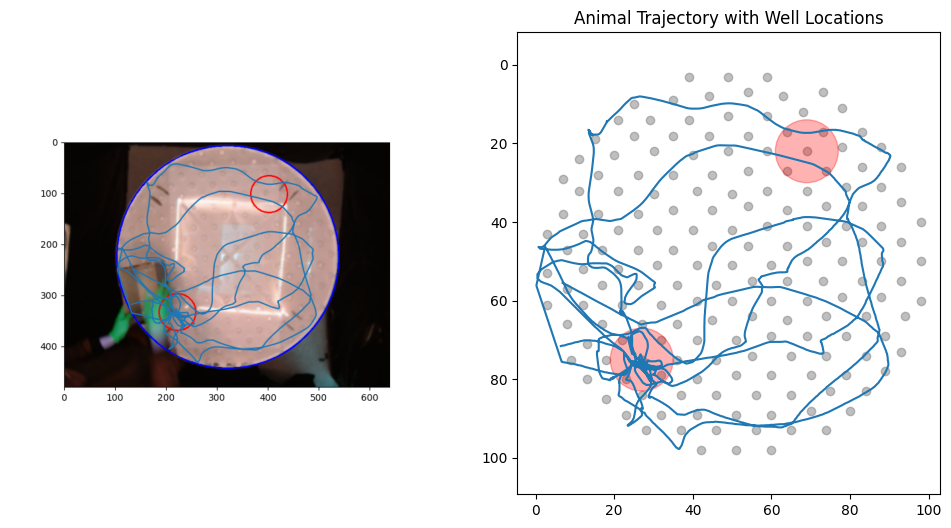

In [19]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(1,2,figsize=(12,6), width_ratios=(1, 1))
axes[0].imshow(img)
axes[0].axis('off')

axes[1].plot(position['x'].values, position['y'].values)
axes[1].scatter(cheeseboardMap['x'].values, cheeseboardMap['y'].values, alpha=0.5, color='gray')
for i in range(len(triggerLoc)):
    x = triggerLoc['x'][i]
    y = triggerLoc['y'][i]
    circle = plt.Circle((x, y), 8, color='r', fill=True, linestyle='-', alpha=0.3)
    axes[1].add_artist(circle)

    # Equalize axis scales
axes[1].axis('equal')
# axes[1].axis('off')
# Flip the y-axis to match the coordinate system
axes[1].invert_yaxis()
axes[1].set_title('Animal Trajectory with Well Locations')

In [24]:
import json
import numpy as np
import pandas as pd
from pathlib import Path

# Assumes these are already available in notebook context:
# - DataLoader
# - ensure_preprocessed_position(position_df)
# - load_ttl_as_lfp_indices(ttl_folder, cont_folder)
# - config (fallback path)
# - meta_ephys


def _merge_intervals(intervals):
    """intervals: list[(start,end)] with start<end. Returns merged sorted list."""
    if not intervals:
        return []
    intervals = sorted(intervals, key=lambda x: x[0])
    merged = [list(intervals[0])]
    for s, e in intervals[1:]:
        if s <= merged[-1][1]:
            merged[-1][1] = max(merged[-1][1], e)
        else:
            merged.append([s, e])
    return [(float(s), float(e)) for s, e in merged]


def _total_duration(spans):
    return float(np.sum([max(0.0, e - s) for s, e in spans])) if spans else 0.0


def _overlap_duration(spans, intervals_merged):
    """Total overlap duration between spans and merged intervals."""
    if not spans or not intervals_merged:
        return 0.0

    spans = sorted(spans, key=lambda x: x[0])
    i = 0
    overlap = 0.0

    for s, e in spans:
        if e <= s:
            continue
        while i < len(intervals_merged) and intervals_merged[i][1] <= s:
            i += 1
        j = i
        while j < len(intervals_merged) and intervals_merged[j][0] < e:
            a, b = intervals_merged[j]
            overlap += max(0.0, min(e, b) - max(s, a))
            if b >= e:
                break
            j += 1

    return float(overlap)


def _get_t_enter_exit_intervals_pos_axis(dl, radius_cm=8.0):
    """
    Return merged [(t_enter,t_exit)] on POSITION axis (seconds).
    Priority:
      1) use position columns t_enter/t_exit if present
      2) fallback: reconstruct from triggerLoc and x/y/t
    """
    pos = ensure_preprocessed_position(dl.get_data("position"))

    if ("t_enter" in pos.columns) and ("t_exit" in pos.columns):
        t_enter = pd.to_numeric(pos["t_enter"], errors="coerce").to_numpy(dtype=float)
        t_exit = pd.to_numeric(pos["t_exit"], errors="coerce").to_numpy(dtype=float)

        max_v = np.nanmax([
            np.nanmax(t_enter) if np.isfinite(t_enter).any() else 0.0,
            np.nanmax(t_exit) if np.isfinite(t_exit).any() else 0.0,
        ])
        if np.isfinite(max_v) and max_v > 1000.0:
            t_enter = t_enter / 1000.0
            t_exit = t_exit / 1000.0

        valid = np.isfinite(t_enter) & np.isfinite(t_exit) & (t_exit > t_enter)
        intervals = [(float(s), float(e)) for s, e in zip(t_enter[valid], t_exit[valid])]
        if intervals:
            return _merge_intervals(intervals)

    # fallback from triggerLoc
    try:
        trigger_loc = dl.get_data("triggerLoc")
    except Exception:
        trigger_loc = None

    if trigger_loc is None or len(trigger_loc) == 0:
        raise ValueError("No t_enter/t_exit and triggerLoc unavailable.")

    if not {"x", "y", "t"}.issubset(pos.columns):
        raise ValueError("Position missing x/y/t; cannot reconstruct intervals.")

    # add distance columns
    p = pos.copy()
    num_triggers = len(trigger_loc)
    for i in range(num_triggers):
        wx = float(trigger_loc["x"].iloc[i])
        wy = float(trigger_loc["y"].iloc[i])
        p[f"dist_to_trigger_{i+1}"] = np.sqrt((p["x"].to_numpy(float) - wx) ** 2 + (p["y"].to_numpy(float) - wy) ** 2)

    intervals = []
    for i in range(num_triggers):
        inside = (p[f"dist_to_trigger_{i+1}"] <= float(radius_cm)).to_numpy(dtype=bool)
        if inside.size == 0:
            continue
        inside[0] = False
        d = np.diff(np.append(inside.astype("int16"), 0))
        enter_idx = np.where(d == 1)[0]
        exit_idx = np.where(d == -1)[0]
        n_pair = min(len(enter_idx), len(exit_idx))
        if n_pair == 0:
            continue
        t_enter = p["t"].to_numpy(dtype=float)[enter_idx[:n_pair]]
        t_exit = p["t"].to_numpy(dtype=float)[exit_idx[:n_pair]]
        valid = np.isfinite(t_enter) & np.isfinite(t_exit) & (t_exit > t_enter)
        intervals.extend([(float(s), float(e)) for s, e in zip(t_enter[valid], t_exit[valid])])

    if not intervals:
        raise ValueError("Failed to reconstruct t_enter/t_exit intervals from triggerLoc.")

    return _merge_intervals(intervals)


def _ttl_spans_on_position_axis_from_alignment_json(info):
    """
    Shift TTL spans to POSITION axis using alignment metadata.
    Same logic as sanity plot:
      ttl_shift_s = ttl_time_shift_s if present else (pad_start_s - trim_start_s)
    """
    cont_dat = Path(str(info.get("continuous_dat", "")))
    if not cont_dat.is_file():
        return [], {"ttl_ok": False, "note": "continuous_dat_missing"}

    rec_dir = cont_dat.parents[2]
    cont_folder = cont_dat.parent
    ttl_folder = rec_dir / "events" / cont_folder.name / "TTL"

    ttl_ok = (
        (ttl_folder / "sample_numbers.npy").is_file()
        and (ttl_folder / "states.npy").is_file()
        and (cont_folder / "sample_numbers.npy").is_file()
    )
    if not ttl_ok:
        return [], {
            "ttl_ok": False,
            "ttl_folder": str(ttl_folder),
            "cont_folder": str(cont_folder),
            "note": "ttl_files_missing",
        }

    fs_raw = float(info.get("fs_raw") or 2000.0)
    trim_s = float(info.get("trim_start_s") or 0.0)
    pad_s = float(info.get("pad_start_s") or 0.0)
    ttl_shift_s = float(info.get("ttl_time_shift_s", pad_s - trim_s))

    pulses_idx_raw = load_ttl_as_lfp_indices(ttl_folder, cont_folder)
    if pulses_idx_raw.size == 0:
        return [], {"ttl_ok": True, "n_pulses": 0, "ttl_shift_s": ttl_shift_s, "note": "no_ttl_pulses"}

    spans_pos = [(float(s) / fs_raw + ttl_shift_s, float(e) / fs_raw + ttl_shift_s) for s, e in pulses_idx_raw]
    spans_pos = [(s, e) for s, e in spans_pos if e > s]

    return spans_pos, {
        "ttl_ok": True,
        "n_pulses": int(len(spans_pos)),
        "ttl_shift_s": ttl_shift_s,
        "note": "ok",
    }


def compute_ttl_in_interval_percentages(meta_ephys, require_aligned=True):
    """
    Trials: trial_type != B and ephys_trial_id != 0
    For each trial:
      1) require aligned npy exists/loads (if require_aligned)
      2) project TTL to position axis using alignment shift
      3) compute % TTL duration inside [t_enter, t_exit] windows (position axis)
    Returns ranked DataFrame (highest % first).
    """
    rows = []

    for i in range(len(meta_ephys)):
        r = meta_ephys.iloc[i]
        meta_row_idx = int(r.name) if r.name is not None else int(i)
        trial_type = str(r.get("trial_type", "")).upper()
        ephys_trial_id = pd.to_numeric(r.get("ephys_trial_id", np.nan), errors="coerce")

        if trial_type == "B":
            continue
        if not (np.isfinite(ephys_trial_id) and int(ephys_trial_id) != 0):
            continue

        dl = DataLoader(metadata_ses=r)

        # resolve alignment json
        try:
            out_dir = Path(dl.generate_preprocess_ephys_filepath())
        except Exception:
            out_dir = Path(config.data_path) / "derivatives" / dl.sub_dir / dl.ses_dir / "ephys" / f"{dl.filename_init}_ephys"

        save_prefix = out_dir.name
        json_path = out_dir / f"{save_prefix}_alignment.json"
        if not json_path.is_file():
            cands = sorted(out_dir.glob("*_alignment.json"))
            if not cands:
                rows.append({
                    "meta_row_idx": meta_row_idx,
                    "id": r.get("id", None),
                    "ses": r.get("ses", None),
                    "trial_id": r.get("trial_id", None),
                    "ephys_trial_id": r.get("ephys_trial_id", None),
                    "trial_type": r.get("trial_type", None),
                    "pct_ttl_in_t_enter_exit": np.nan,
                    "ttl_total_s": np.nan,
                    "ttl_in_intervals_s": np.nan,
                    "n_ttl_pulses": np.nan,
                    "ttl_shift_s": np.nan,
                    "note": "missing_alignment_json",
                })
                continue
            json_path = cands[0]

        info = json.loads(json_path.read_text())

        # enforce aligned npy exists/loads if requested
        aligned_path = info.get("aligned_path", None)
        if require_aligned:
            aligned_ok = False
            aligned_err = None

            if aligned_path:
                try:
                    _ = np.load(aligned_path, mmap_mode="r")
                    aligned_ok = True
                except Exception as e:
                    aligned_ok = False
                    aligned_err = repr(e)

            # fallback: if json path missing/bad, try DataLoader aligned ephys accessor
            if not aligned_ok:
                try:
                    _ = dl.get_data("ephys")
                    aligned_ok = True
                except Exception as e:
                    aligned_ok = False
                    if aligned_err is None:
                        aligned_err = repr(e)

            if not aligned_ok:
                print("\n" + "="*90)
                print("ALIGNED NPY MISSING / UNLOADABLE")
                print(f"meta_ephys row index (meta_row_idx): {meta_row_idx}")
                print(f"aligned_path (from json): {aligned_path}")
                if aligned_err is not None:
                    print(f"load error: {aligned_err}")

                # Print the FULL row (nice formatting)
                try:
                    print("\nmeta_ephys row:")
                    display(meta_ephys.loc[[meta_row_idx]])
                except Exception:
                    # fallback if display not available
                    print(meta_ephys.loc[meta_row_idx].to_string())

                print("="*90 + "\n")

                rows.append({
                    "meta_row_idx": meta_row_idx,
                    "id": r.get("id", None),
                    "ses": r.get("ses", None),
                    "trial_id": r.get("trial_id", None),
                    "ephys_trial_id": r.get("ephys_trial_id", None),
                    "trial_type": r.get("trial_type", None),
                    "pct_ttl_in_t_enter_exit": np.nan,
                    "ttl_total_s": np.nan,
                    "ttl_in_intervals_s": np.nan,
                    "n_ttl_pulses": np.nan,
                    "ttl_shift_s": np.nan,
                    "note": "aligned_missing_or_unloadable",
                })
                continue

        # t_enter/t_exit intervals on position axis
        try:
            intervals_merged = _get_t_enter_exit_intervals_pos_axis(dl)
        except Exception as e:
            rows.append({
                "meta_row_idx": meta_row_idx,
                "id": r.get("id", None),
                "ses": r.get("ses", None),
                "trial_id": r.get("trial_id", None),
                "ephys_trial_id": r.get("ephys_trial_id", None),
                "trial_type": r.get("trial_type", None),
                "pct_ttl_in_t_enter_exit": np.nan,
                "ttl_total_s": np.nan,
                "ttl_in_intervals_s": np.nan,
                "n_ttl_pulses": np.nan,
                "ttl_shift_s": np.nan,
                "note": f"intervals_failed:{repr(e)}",
            })
            continue

        ttl_spans_pos, ttl_meta = _ttl_spans_on_position_axis_from_alignment_json(info)
        ttl_total = _total_duration(ttl_spans_pos)
        ttl_in = _overlap_duration(ttl_spans_pos, intervals_merged)

        pct = np.nan
        if ttl_total > 0:
            pct = 100.0 * (ttl_in / ttl_total)

        rows.append({
            "meta_row_idx": meta_row_idx,
            "id": r.get("id", None),
            "ses": r.get("ses", None),
            "trial_id": r.get("trial_id", None),
            "ephys_trial_id": r.get("ephys_trial_id", None),
            "trial_type": r.get("trial_type", None),
            "pct_ttl_in_t_enter_exit": pct,
            "ttl_total_s": ttl_total,
            "ttl_in_intervals_s": ttl_in,
            "n_ttl_pulses": ttl_meta.get("n_pulses", np.nan) if ttl_meta.get("ttl_ok") else np.nan,
            "ttl_shift_s": ttl_meta.get("ttl_shift_s", np.nan) if ttl_meta.get("ttl_ok") else np.nan,
            "note": "ok" if ttl_total > 0 else ("no_ttl" if ttl_meta.get("ttl_ok") else ttl_meta.get("note", "ttl_missing_files")),
        })

    df_out = pd.DataFrame(rows)
    if "meta_row_idx" not in df_out.columns:
        df_out["meta_row_idx"] = pd.NA
    df_ranked = df_out.sort_values(
        by=["pct_ttl_in_t_enter_exit", "ttl_total_s"],
        ascending=[False, False],
        na_position="last",
    ).reset_index(drop=True)

    return df_ranked


# -----------------------------
# RUN
# -----------------------------
df_ttl_pct = compute_ttl_in_interval_percentages(meta_ephys, require_aligned=True)
display(df_ttl_pct)

cols_show = [
    "meta_row_idx", "id", "ses", "trial_id", "ephys_trial_id", "trial_type",
    "pct_ttl_in_t_enter_exit", "ttl_total_s", "ttl_in_intervals_s",
    "n_ttl_pulses", "ttl_shift_s", "note"
]
display(df_ttl_pct[[c for c in cols_show if c in df_ttl_pct.columns]])

print("\nNote counts:")
print(df_ttl_pct["note"].value_counts(dropna=False))

valid_pct = df_ttl_pct["pct_ttl_in_t_enter_exit"].notna().sum()
print(f"\nTrials with valid percentage: {valid_pct} / {len(df_ttl_pct)}")






The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-017_id-AN/ses-43_date-20251007/ephys/sub-017_ses-43_trial-04_ephys/sub-017_ses-43_trial-04_ephys_aligned.npy' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-017_id-AN/ses-44_date-20251008/ephys/sub-017_ses-44_trial-02_ephys/sub-017_ses-44_trial-02_ephys_aligned.npy' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-017_id-AN/ses-44_date-20251008/ephys/sub-017_ses-44_trial-04_ephys/sub-017_ses-44_trial-04_ephys_aligned.npy' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-017_id-AN/ses-44_date-20251008/ephys/sub-017_ses-44_trial-16_ephys/sub-017_ses-44_trial-16_ephys_aligned.npy' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-da

,meta_row_idx,id,ses,trial_id,ephys_trial_id,trial_type,pct_ttl_in_t_enter_exit,ttl_total_s,ttl_in_intervals_s,n_ttl_pulses,ttl_shift_s,note
0,1085,AN,47,6,13,RL,100.0,4.5635,4.5635,775.0,-2.837,ok
1,873,AN,29,5,10,L,100.0,2.5140,2.5140,425.0,-5.455,ok
2,1496,AO,34,1,2,T,100.0,2.4520,2.4520,416.0,-9.130,ok
3,1479,AO,33,1,2,L,100.0,2.3585,2.3585,400.0,-5.375,ok
4,869,AN,29,3,6,L,100.0,1.2660,1.2660,215.0,1.491,ok
...,...,...,...,...,...,...,...,...,...,...,...,...
356,1038,AN,44,8,16,RL,NaN,NaN,NaN,NaN,NaN,intervals_failed:ValueError('Failed to reconst...
357,1041,AN,45,1,2,RL,NaN,NaN,NaN,NaN,NaN,intervals_failed:ValueError('Failed to reconst...
358,1055,AN,45,8,16,RL,NaN,NaN,NaN,NaN,NaN,intervals_failed:ValueError('Failed to reconst...
359,1058,AN,46,1,2,RL,NaN,NaN,NaN,NaN,NaN,intervals_failed:ValueError('Failed to reconst...


,meta_row_idx,id,ses,trial_id,ephys_trial_id,trial_type,pct_ttl_in_t_enter_exit,ttl_total_s,ttl_in_intervals_s,n_ttl_pulses,ttl_shift_s,note
0,1085,AN,47,6,13,RL,100.0,4.5635,4.5635,775.0,-2.837,ok
1,873,AN,29,5,10,L,100.0,2.5140,2.5140,425.0,-5.455,ok
2,1496,AO,34,1,2,T,100.0,2.4520,2.4520,416.0,-9.130,ok
3,1479,AO,33,1,2,L,100.0,2.3585,2.3585,400.0,-5.375,ok
4,869,AN,29,3,6,L,100.0,1.2660,1.2660,215.0,1.491,ok
...,...,...,...,...,...,...,...,...,...,...,...,...
356,1038,AN,44,8,16,RL,NaN,NaN,NaN,NaN,NaN,intervals_failed:ValueError('Failed to reconst...
357,1041,AN,45,1,2,RL,NaN,NaN,NaN,NaN,NaN,intervals_failed:ValueError('Failed to reconst...
358,1055,AN,45,8,16,RL,NaN,NaN,NaN,NaN,NaN,intervals_failed:ValueError('Failed to reconst...
359,1058,AN,46,1,2,RL,NaN,NaN,NaN,NaN,NaN,intervals_failed:ValueError('Failed to reconst...



Note counts:
note
ok                                                                                                353
intervals_failed:ValueError('Failed to reconstruct t_enter/t_exit intervals from triggerLoc.')      7
intervals_failed:ValueError('Position is empty or None.')                                           1
Name: count, dtype: int64

Trials with valid percentage: 353 / 361


In [33]:
import pandas as pd

target_path = "/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/meta_ephys_matched90below.csv"
source_path = "/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/Cell 24.csv"

target = pd.read_csv(target_path)
source = pd.read_csv(source_path)

# Clean headers
for df in (target, source):
    df.columns = (
        df.columns
        .str.replace("\ufeff", "", regex=False)
        .str.strip()
        .str.replace("-", "_", regex=False)
    )

key_cols = ["id", "ses", "trial_id", "ephys_trial_id"]
pct_col = "pct_ttl_in_t_enter_exit"

# Checks
for name, df in [("target", target), ("source", source)]:
    missing = [c for c in key_cols if c not in df.columns]
    if missing:
        raise KeyError(f"{name} missing key columns: {missing}")

if pct_col not in source.columns:
    raise KeyError(f"source missing '{pct_col}'")

# Normalize key + pct types
for c in ["ses", "trial_id", "ephys_trial_id"]:
    target[c] = pd.to_numeric(target[c], errors="coerce")
    source[c] = pd.to_numeric(source[c], errors="coerce")

target["id"] = target["id"].astype(str).str.strip()
source["id"] = source["id"].astype(str).str.strip()
source[pct_col] = pd.to_numeric(source[pct_col], errors="coerce")

# Safety: no duplicate keys in source
dups = source.duplicated(key_cols, keep=False)
if dups.any():
    raise ValueError("Source has duplicate trial keys; cannot merge safely.")

# Merge pct from Cell 24
src_small = source[key_cols + [pct_col]]
merged = target.merge(src_small, on=key_cols, how="left", suffixes=("", "_src"), validate="m:1")

if pct_col in merged.columns and f"{pct_col}_src" in merged.columns:
    merged[pct_col] = pd.to_numeric(merged[pct_col], errors="coerce").fillna(
        pd.to_numeric(merged[f"{pct_col}_src"], errors="coerce")
    )
    merged.drop(columns=[f"{pct_col}_src"], inplace=True)
elif f"{pct_col}_src" in merged.columns:
    merged.rename(columns={f"{pct_col}_src": pct_col}, inplace=True)

# Update match only if empty; do not overwrite existing 0/1
if "match" not in merged.columns:
    merged["match"] = pd.NA
merged["match"] = merged["match"].replace(r"^\s*$", pd.NA, regex=True)

mask = merged["match"].isna() & (pd.to_numeric(merged[pct_col], errors="coerce") >= 90)
merged.loc[mask, "match"] = 1

print(f"Rows updated to match=1: {int(mask.sum())}")

merged.to_csv(target_path, index=False)
print("Saved:", target_path)

Rows updated to match=1: 251
Saved: /Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/meta_ephys_matched90below.csv


In [26]:
# Show matched rows from meta_ephys (+ row index)
show_cols = [
    "meta_row_idx",
    "id", "id_meta", "id_missing",
    "date", "date_meta", "date_missing",
    "ses", "ses_meta", "ses_missing",
    "trial_id", "trial_type",
    "ephys_trial_id", "ephys_trial_id_meta", "ephys_trial_id_missing",
    "ephys_usable",
]
show_cols = [c for c in show_cols if c in merged.columns]

sort_pref = ["id", "id_meta", "id_missing",
             "ses", "ses_meta", "ses_missing",
             "ephys_trial_id", "ephys_trial_id_meta", "ephys_trial_id_missing",
             "meta_row_idx"]
sort_cols = [c for c in sort_pref if c in merged.columns]

print("Matched rows in meta_ephys:")
display(merged[show_cols].sort_values(sort_cols))

# robust not-found block
nf_cols_pref = ["id_missing", "date_missing", "ses_missing", "ephys_trial_id_missing",
                "id", "date", "ses", "ephys_trial_id"]
nf_cols = [c for c in nf_cols_pref if c in merged.columns]
not_found = merged[merged["meta_row_idx"].isna()][nf_cols]

if len(not_found):
    print("Entries not found in meta_ephys:")
    display(not_found.drop_duplicates().reset_index(drop=True))


NameError: name 'merged' is not defined

Rows to review: 102

[show] review_pos=1/102 | df_ttl_pct idx=352 | meta_ephys row=1428
id=AO ses=30 trial_id=1 ephys_trial_id=2
pct_ttl_in_t_enter_exit=0.0 | note=ok | current match=<NA>
Position raw data path: /Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-018_id-AO/ses-30_date-20250921/behav/sub-018_ses-30_trial-01_data-position.csv


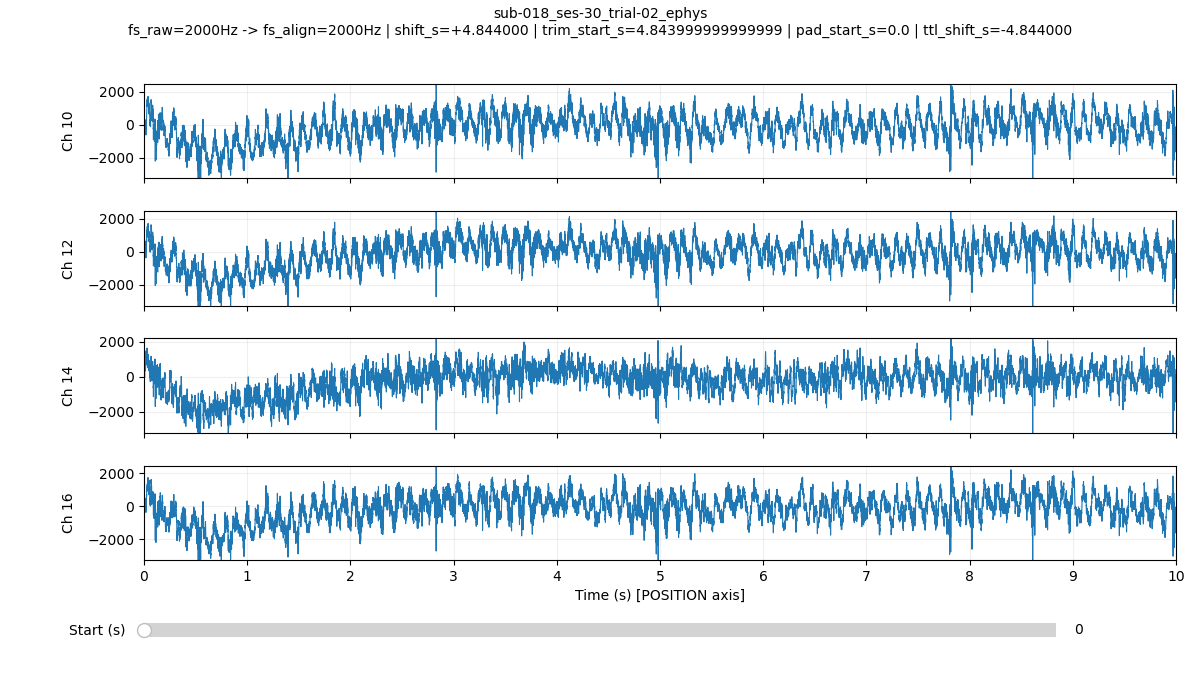

Plot rendered. Now run Cell B to enter label and advance.


In [25]:
# ============================================================
# Manual review (NON-BLOCKING) - Cell A: show current trial plot
# Run this cell to render sanity slider for current review_pos.
# ============================================================

try:
    get_ipython().run_line_magic("matplotlib", "widget")
except Exception:
    pass

import pandas as pd
import numpy as np
import util.test_data_loader as tdl

DataLoader = tdl.DataLoader

# ---- config ----
FS_RAW = 2000.0
CHANNELS = (10, 12, 14, 16)
WINDOW_S = 10

# Ensure output columns exist
if "match" not in df_ttl_pct.columns:
    df_ttl_pct["match"] = pd.NA
if "match" not in meta_ephys.columns:
    meta_ephys["match"] = pd.NA

# Build candidate list once (or rebuild if not present)
if "to_review" not in globals() or to_review is None or len(to_review) == 0:
    to_review = (
        df_ttl_pct[
            pd.to_numeric(df_ttl_pct["pct_ttl_in_t_enter_exit"], errors="coerce").lt(90)
            & pd.to_numeric(df_ttl_pct["pct_ttl_in_t_enter_exit"], errors="coerce").notna()
        ]
        .sort_values("pct_ttl_in_t_enter_exit", ascending=True)
        .copy()
    )

if "review_pos" not in globals() or review_pos is None:
    review_pos = 0

if to_review.empty:
    print("No rows with pct_ttl_in_t_enter_exit < 90.")
else:
    print(f"Rows to review: {len(to_review)}")


def _resolve_meta_row_idx(r):
    if "meta_row_idx" in r.index and pd.notna(r["meta_row_idx"]):
        return int(r["meta_row_idx"])

    m = meta_ephys.copy()
    cond = (
        m["id"].astype(str).str.upper().eq(str(r.get("id", "")).upper())
        & pd.to_numeric(m["ses"], errors="coerce").eq(pd.to_numeric(r.get("ses"), errors="coerce"))
        & pd.to_numeric(m["ephys_trial_id"], errors="coerce").eq(pd.to_numeric(r.get("ephys_trial_id"), errors="coerce"))
    )
    if "trial_id" in m.columns and "trial_id" in r.index and pd.notna(r.get("trial_id")):
        cond = cond & pd.to_numeric(m["trial_id"], errors="coerce").eq(pd.to_numeric(r.get("trial_id"), errors="coerce"))

    idxs = m.index[cond]
    return int(idxs[0]) if len(idxs) else None


# Find next valid row from current review_pos
current_review_df_idx = None
current_meta_idx = None
for pos in range(review_pos, len(to_review)):
    cand_idx = to_review.index[pos]
    r = df_ttl_pct.loc[cand_idx]
    m_idx = _resolve_meta_row_idx(r)
    if m_idx is not None:
        current_review_df_idx = cand_idx
        current_meta_idx = m_idx
        review_pos = pos
        break

if current_review_df_idx is None:
    print("No more resolvable rows to review.")
else:
    r = df_ttl_pct.loc[current_review_df_idx]
    print("\n" + "=" * 70)
    print(f"[show] review_pos={review_pos+1}/{len(to_review)} | df_ttl_pct idx={current_review_df_idx} | meta_ephys row={current_meta_idx}")
    print(f"id={r.get('id')} ses={r.get('ses')} trial_id={r.get('trial_id')} ephys_trial_id={r.get('ephys_trial_id')}")
    print(f"pct_ttl_in_t_enter_exit={r.get('pct_ttl_in_t_enter_exit')} | note={r.get('note')} | current match={r.get('match')}")

    dl = DataLoader(metadata_ses=meta_ephys.iloc[current_meta_idx])
    print("Position raw data path:", dl.generate_filepath("position", "derivatives", "behav", "csv"))

    _ = sanity_slider_alignment_saved(
        dl=dl,
        fs_raw=FS_RAW,
        channels=CHANNELS,
        window_s=WINDOW_S,
    )
    print("Plot rendered. Now run Cell B to enter label and advance.")




In [283]:
# ============================================================
# Manual review - Cell B: label current row and advance
# Run after Cell A renders the plot.
# ============================================================

if "current_review_df_idx" not in globals() or current_review_df_idx is None:
    print("Run Cell A first to load a current row/plot.")
else:
    ans = input("Enter match (1/0), s=skip, q=quit: ").strip().lower()

    if ans in {"1", "0"}:
        v = int(ans)
        df_ttl_pct.at[current_review_df_idx, "match"] = v
        if "current_meta_idx" in globals() and current_meta_idx is not None:
            meta_ephys.at[current_meta_idx, "match"] = v
        print(f"Saved match={v} for df idx {current_review_df_idx}, meta row {current_meta_idx}.")
        review_pos = int(review_pos) + 1
        print("Advanced. Run Cell A for next trial.")

    elif ans == "s":
        print(f"Skipped df idx {current_review_df_idx}.")
        review_pos = int(review_pos) + 1
        print("Advanced. Run Cell A for next trial.")

    elif ans == "q":
        print("Stopped review loop.")

    else:
        print("Invalid input. Use 1, 0, s, or q.")

print("\nCurrent label counts:")
print(df_ttl_pct["match"].value_counts(dropna=False))



Saved match=1 for df idx 251, meta row 1092.
Advanced. Run Cell A for next trial.

Current label counts:
match
<NA>    260
1        92
0         9
Name: count, dtype: int64
